# VITALS - Model Training & Evaluation Notebook
## AI-Powered Chronic Disease Risk Prediction System

This notebook covers:
1. Data Loading & Preprocessing
2. Feature Engineering
3. Model Training (4-model Ensemble)
4. Confusion Matrix
5. ROC Curve
6. Classification Report
7. Feature Importance
8. Individual Model Comparison
9. Cross-Validation Results

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (classification_report, accuracy_score, roc_auc_score,
                             f1_score, precision_score, recall_score,
                             confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('All imports successful!')

All imports successful!


## 1. Load Preprocessed Dataset

In [2]:
df = pd.read_csv('data/final_health_dataset.csv')
print(f'Dataset Shape: {df.shape}')
print(f'\nColumn List ({len(df.columns)}):')
print(list(df.columns))
print(f'\nTarget Distribution:')
print(df['target'].value_counts())
print(f'\nTarget Distribution (%):')
print(df['target'].value_counts(normalize=True).round(4) * 100)
df.head()

Dataset Shape: (129436, 23)

Column List (23):
['age', 'gender', 'bmi', 'blood_pressure', 'cholesterol', 'glucose', 'smoking_status', 'physical_activity', 'alcohol_intake', 'target', 'age_group', 'bmi_category', 'bp_category', 'glucose_category', 'pulse_pressure', 'metabolic_risk', 'bmi_glucose_interaction', 'age_bp_interaction', 'smoking_bp_risk', 'smoking_glucose_risk', 'activity_bmi_risk', 'activity_glucose_risk', 'alcohol_liver_risk']

Target Distribution:
target
1    66453
0    62983
Name: count, dtype: int64

Target Distribution (%):
target
1    51.34
0    48.66
Name: proportion, dtype: float64


,age,gender,bmi,blood_pressure,cholesterol,glucose,smoking_status,physical_activity,alcohol_intake,target,...,glucose_category,pulse_pressure,metabolic_risk,bmi_glucose_interaction,age_bp_interaction,smoking_bp_risk,smoking_glucose_risk,activity_bmi_risk,activity_glucose_risk,alcohol_liver_risk
0,52.0,1,23.32,125.0,212.0,82.936511,0,2,0,0,...,1,50.0,91.051302,1.934079,6.500,0.000000,0.000000,1.554667,1.658730,0.0
1,53.0,1,23.33,140.0,203.0,110.571947,1,2,0,0,...,2,56.0,98.480389,2.579644,7.420,1.000000,1.105719,1.555333,2.211439,0.0
2,70.0,1,24.74,145.0,174.0,119.649753,0,2,0,0,...,2,58.0,101.477951,2.960135,10.150,0.000000,0.000000,1.649333,2.392995,0.0
3,61.0,1,24.13,148.0,203.0,89.035955,0,2,0,0,...,1,59.2,97.933191,2.148438,9.028,0.000000,0.000000,1.608667,1.780719,0.0
4,62.0,0,25.14,138.0,294.0,104.083398,1,2,0,0,...,2,55.2,113.044680,2.616657,8.556,0.985714,1.040834,1.676000,2.081668,0.0


## 2. Feature Engineering

In [3]:
FEATURE_COLS = [
    'age', 'gender', 'bmi', 'blood_pressure', 'cholesterol',
    'glucose', 'smoking_status', 'physical_activity', 'alcohol_intake',
    'age_group', 'bmi_category', 'bp_category', 'glucose_category',
    'pulse_pressure', 'metabolic_risk', 'bmi_glucose_interaction', 'age_bp_interaction',
    'smoking_bp_risk', 'smoking_glucose_risk', 'activity_bmi_risk', 'activity_glucose_risk', 'alcohol_liver_risk'
]

X = df[FEATURE_COLS]
y = df['target']

print(f'Features: {len(FEATURE_COLS)}')
print(f'Samples: {len(X)}')
print(f'\nFeature Categories:')
print(f'  Raw Input (9): {FEATURE_COLS[:9]}')
print(f'  Categorical Bins (4): {FEATURE_COLS[9:13]}')
print(f'  Clinical Interactions (4): {FEATURE_COLS[13:17]}')
print(f'  Behavioral Interactions (5): {FEATURE_COLS[17:]}')

Features: 22
Samples: 129436

Feature Categories:
  Raw Input (9): ['age', 'gender', 'bmi', 'blood_pressure', 'cholesterol', 'glucose', 'smoking_status', 'physical_activity', 'alcohol_intake']
  Categorical Bins (4): ['age_group', 'bmi_category', 'bp_category', 'glucose_category']
  Clinical Interactions (4): ['pulse_pressure', 'metabolic_risk', 'bmi_glucose_interaction', 'age_bp_interaction']
  Behavioral Interactions (5): ['smoking_bp_risk', 'smoking_glucose_risk', 'activity_bmi_risk', 'activity_glucose_risk', 'alcohol_liver_risk']


## 3. Train-Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training Set: {X_train.shape[0]} samples')
print(f'Test Set: {X_test.shape[0]} samples')
print(f'\nTrain Target Distribution:')
print(y_train.value_counts(normalize=True).round(4) * 100)
print(f'\nTest Target Distribution:')
print(y_test.value_counts(normalize=True).round(4) * 100)

Training Set: 103548 samples
Test Set: 25888 samples

Train Target Distribution:
target
1    51.34
0    48.66
Name: proportion, dtype: float64

Test Target Distribution:
target
1    51.34
0    48.66
Name: proportion, dtype: float64


## 4. Define Individual Models

In [5]:
# Class imbalance handling
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)
print(f'Scale Pos Weight: {scale_pos_weight:.4f}')

# XGBoost
xgb = XGBClassifier(
    objective='binary:logistic', eval_metric='logloss',
    n_estimators=400, max_depth=6, learning_rate=0.05,
    subsample=0.85, colsample_bytree=0.85,
    scale_pos_weight=scale_pos_weight,
    min_child_weight=3, gamma=0.1, reg_alpha=0.05, reg_lambda=1.0,
    random_state=42, n_jobs=1
)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_split=5,
    min_samples_leaf=2, class_weight='balanced',
    random_state=42, n_jobs=1
)

# Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=250, learning_rate=0.08, max_depth=5,
    subsample=0.8, min_samples_split=5, random_state=42
)

# Logistic Regression
lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        max_iter=1000, C=1.0, class_weight='balanced',
        solver='lbfgs', random_state=42
    ))
])

print('All 4 models defined:')
print('  1. XGBoost (weight=3)')
print('  2. Random Forest (weight=2)')
print('  3. Gradient Boosting (weight=2)')
print('  4. Logistic Regression (weight=1)')

Scale Pos Weight: 0.9478
All 4 models defined:
  1. XGBoost (weight=3)
  2. Random Forest (weight=2)
  3. Gradient Boosting (weight=2)
  4. Logistic Regression (weight=1)


## 5. Build & Train Ensemble

In [6]:
ensemble = VotingClassifier(
    estimators=[
        ('xgb', xgb),
        ('rf', rf),
        ('gb', gb),
        ('lr', lr)
    ],
    voting='soft',
    weights=[3, 2, 2, 1]
)

print('Training ensemble (this may take a few minutes)...')
ensemble.fit(X_train, y_train)
print('Training complete!')

Training ensemble (this may take a few minutes)...


Training complete!


## 6. Threshold Optimization

Optimal Threshold: 0.43
Best F1: 0.8426

Threshold vs F1 Score:
 Threshold       F1  Precision   Recall
      0.05 0.741877   0.591250 0.995486
      0.07 0.755595   0.609718 0.993229
      0.09 0.764993   0.623148 0.990445
      0.11 0.774801   0.637361 0.987811
      0.13 0.782406   0.648922 0.985027
      0.15 0.790381   0.660883 0.982996
      0.17 0.796695   0.671482 0.979309
      0.19 0.802442   0.682137 0.974268
      0.21 0.808187   0.694156 0.967045
      0.23 0.815660   0.710261 0.957791
      0.25 0.822436   0.725797 0.948762
      0.27 0.826472   0.739112 0.937251
      0.29 0.830561   0.751691 0.927921
      0.31 0.833886   0.763639 0.918366
      0.33 0.837348   0.776250 0.908886
      0.35 0.838527   0.784166 0.900986
      0.37 0.838975   0.793902 0.889474
      0.39 0.840136   0.806577 0.876608
      0.41 0.842155   0.818446 0.867279
      0.43 0.842606   0.826128 0.859755
      0.45 0.841337   0.833235 0.849597
      0.47 0.840897   0.841150 0.840644
      0.49 0.839

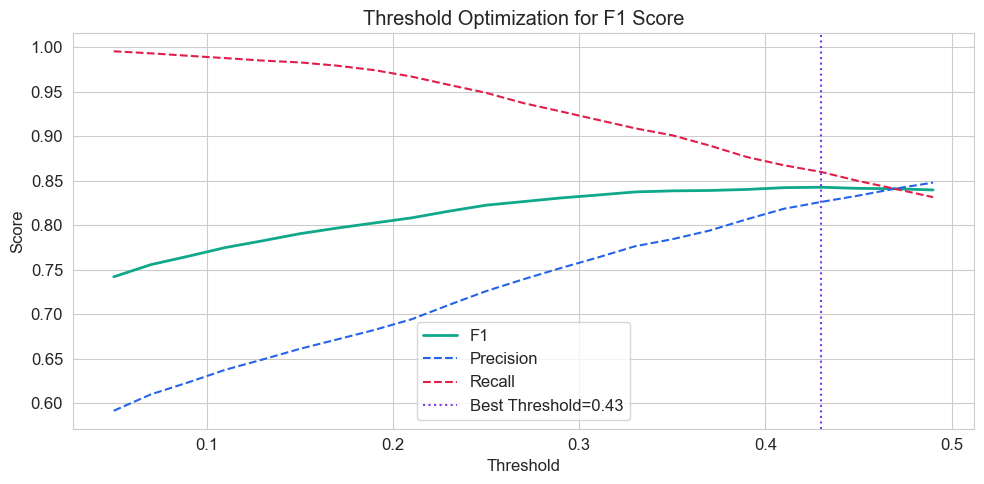

In [7]:
y_probs = ensemble.predict_proba(X_test)[:, 1]

# Find optimal threshold for best F1
thresholds = np.arange(0.05, 0.5, 0.02)
results = []

for t in thresholds:
    y_pred_t = (y_probs >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    rec = recall_score(y_test, y_pred_t)
    results.append((t, f1, prec, rec))

results_df = pd.DataFrame(results, columns=['Threshold', 'F1', 'Precision', 'Recall'])
best_idx = results_df['F1'].idxmax()
best_threshold = results_df.loc[best_idx, 'Threshold']

print(f'Optimal Threshold: {best_threshold:.2f}')
print(f'Best F1: {results_df.loc[best_idx, "F1"]:.4f}')
print(f'\nThreshold vs F1 Score:')
print(results_df.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.plot(results_df['Threshold'], results_df['F1'], label='F1', linewidth=2, color='#0fa88a')
plt.plot(results_df['Threshold'], results_df['Precision'], label='Precision', linewidth=1.5, color='#2563eb', linestyle='--')
plt.plot(results_df['Threshold'], results_df['Recall'], label='Recall', linewidth=1.5, color='#e11d48', linestyle='--')
plt.axvline(x=best_threshold, color='#7c3aed', linestyle=':', label=f'Best Threshold={best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Optimization for F1 Score')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Confusion Matrix

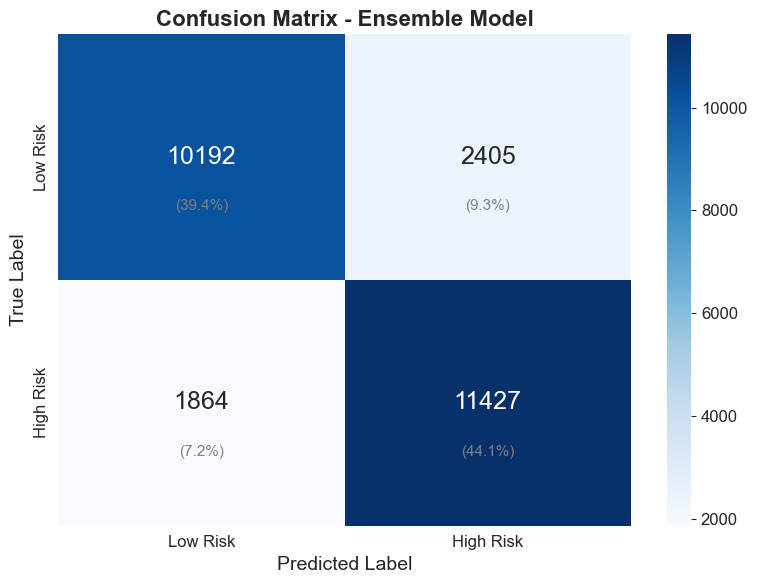

True Negatives (Low Risk correct):  10192
False Positives (Low→High wrong):   2405
False Negatives (High→Low wrong):   1864
True Positives (High Risk correct): 11427

Specificity: 0.8091
Sensitivity (Recall): 0.8598


In [8]:
y_pred = (y_probs > best_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Risk', 'High Risk'],
            yticklabels=['Low Risk', 'High Risk'],
            annot_kws={'size': 18}, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=14)
ax.set_ylabel('True Label', fontsize=14)
ax.set_title('Confusion Matrix - Ensemble Model', fontsize=16, fontweight='bold')

# Add percentage annotations
total = cm.sum()
for i in range(2):
    for j in range(2):
        pct = cm[i][j] / total * 100
        ax.text(j + 0.5, i + 0.7, f'({pct:.1f}%)', ha='center', va='center', fontsize=11, color='gray')

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives (Low Risk correct):  {tn}')
print(f'False Positives (Low→High wrong):   {fp}')
print(f'False Negatives (High→Low wrong):   {fn}')
print(f'True Positives (High Risk correct): {tp}')
print(f'\nSpecificity: {tn/(tn+fp):.4f}')
print(f'Sensitivity (Recall): {tp/(tp+fn):.4f}')

## 8. ROC Curve

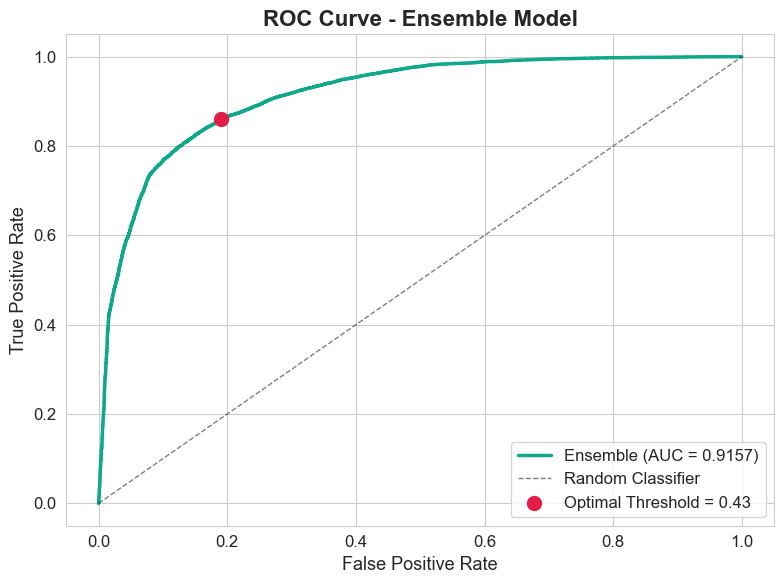

ROC-AUC Score: 0.9157


In [9]:
fpr, tpr, roc_thresholds = roc_curve(y_test, y_probs)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#0fa88a', linewidth=2.5, label=f'Ensemble (AUC = {roc_auc_val:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random Classifier')

# Mark the optimal threshold point
optimal_idx = np.argmin(np.abs(roc_thresholds - best_threshold))
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='#e11d48', s=100, zorder=5,
            label=f'Optimal Threshold = {best_threshold:.2f}')

plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curve - Ensemble Model', fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f'ROC-AUC Score: {roc_auc_val:.4f}')

## 9. Classification Report

In [10]:
print('=' * 60)
print('  CLASSIFICATION REPORT - ENSEMBLE MODEL')
print('=' * 60)
print(classification_report(y_test, y_pred, target_names=['Low Risk', 'High Risk']))

print('=' * 60)
print('  SUMMARY METRICS')
print('=' * 60)
print(f'Accuracy:    {accuracy_score(y_test, y_pred):.4f}')
print(f'ROC-AUC:     {roc_auc_score(y_test, y_probs):.4f}')
print(f'Precision:   {precision_score(y_test, y_pred):.4f}')
print(f'Recall:      {recall_score(y_test, y_pred):.4f}')
print(f'F1 Score:    {f1_score(y_test, y_pred):.4f}')
print(f'Threshold:   {best_threshold:.2f}')

  CLASSIFICATION REPORT - ENSEMBLE MODEL
              precision    recall  f1-score   support

    Low Risk       0.85      0.81      0.83     12597
   High Risk       0.83      0.86      0.84     13291

    accuracy                           0.84     25888
   macro avg       0.84      0.83      0.83     25888
weighted avg       0.84      0.84      0.83     25888

  SUMMARY METRICS


Accuracy:    0.8351
ROC-AUC:     0.9157
Precision:   0.8261
Recall:      0.8598
F1 Score:    0.8426
Threshold:   0.43


## 10. Individual Model Comparison

                 Model Weight  Accuracy  ROC-AUC       F1  Precision   Recall
               XGBoost      3  0.836951 0.916420 0.838096   0.854851 0.821985
         Random Forest      2  0.836295 0.916135 0.837512   0.853882 0.821759
     Gradient Boosting      2  0.835831 0.915739 0.837724   0.850454 0.825371
   Logistic Regression      1  0.783336 0.857788 0.787449   0.793251 0.781732
Ensemble (Soft Voting)      -  0.835097 0.915724 0.842606   0.826128 0.859755


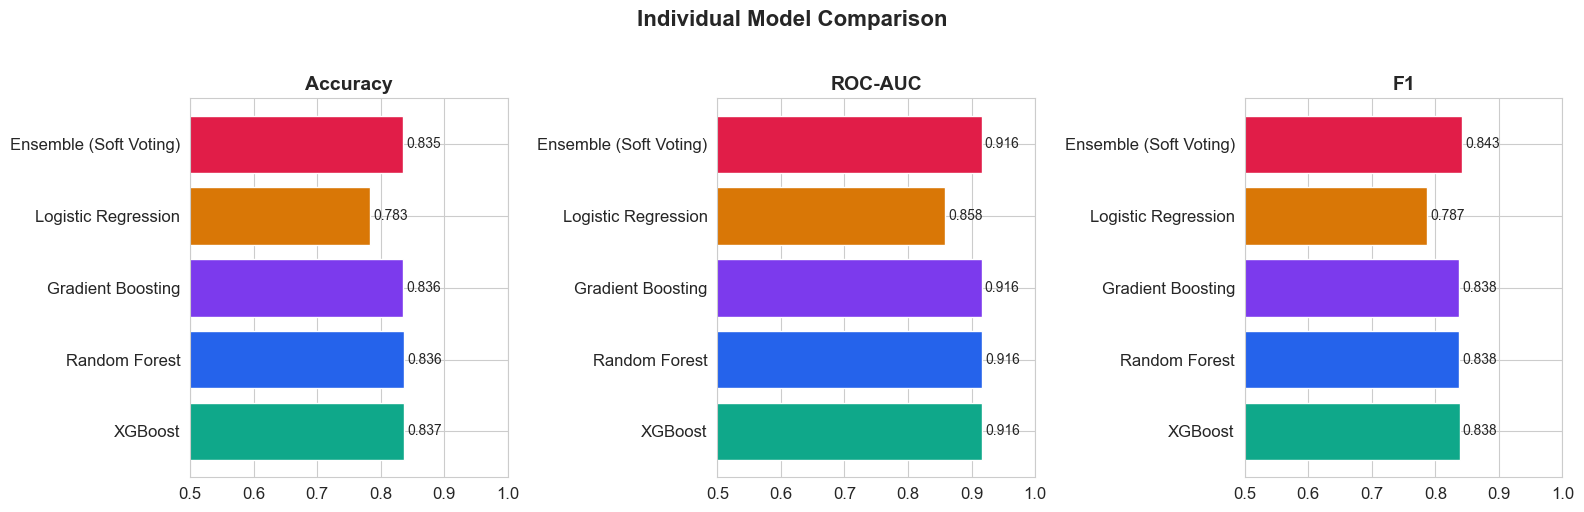

In [11]:
model_names = ['XGBoost', 'Random Forest', 'Gradient Boosting', 'Logistic Regression']
models = [xgb, rf, gb, lr]
model_weights = [3, 2, 2, 1]

comparison = []

for name, model, weight in zip(model_names, models, model_weights):
    model.fit(X_train, y_train)
    y_p = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    comparison.append({
        'Model': name,
        'Weight': weight,
        'Accuracy': accuracy_score(y_test, y_p),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'F1': f1_score(y_test, y_p),
        'Precision': precision_score(y_test, y_p),
        'Recall': recall_score(y_test, y_p)
    })

# Add ensemble
comparison.append({
    'Model': 'Ensemble (Soft Voting)',
    'Weight': '-',
    'Accuracy': accuracy_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_probs),
    'F1': f1_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred)
})

comp_df = pd.DataFrame(comparison)
print(comp_df.to_string(index=False))

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#0fa88a', '#2563eb', '#7c3aed', '#d97706', '#e11d48']

for i, metric in enumerate(['Accuracy', 'ROC-AUC', 'F1']):
    bars = axes[i].barh(comp_df['Model'], comp_df[metric], color=colors)
    axes[i].set_title(metric, fontsize=14, fontweight='bold')
    axes[i].set_xlim(0.5, 1.0)
    for bar, val in zip(bars, comp_df[metric]):
        if isinstance(val, float):
            axes[i].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                        f'{val:.3f}', va='center', fontsize=10)

plt.suptitle('Individual Model Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 11. ROC Curves - All Models

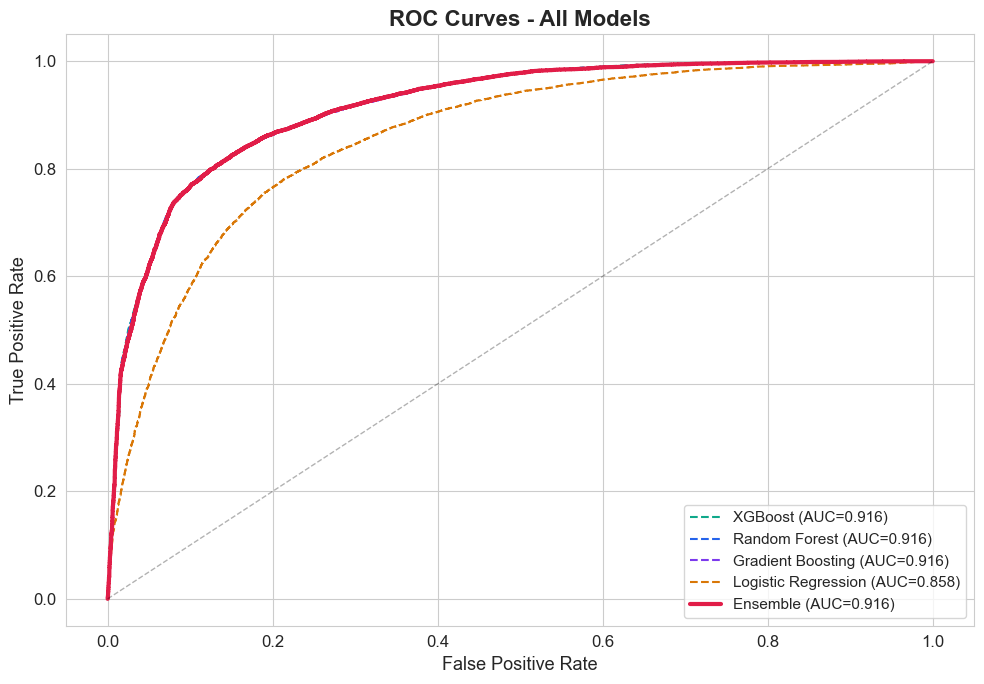

In [12]:
plt.figure(figsize=(10, 7))
colors_roc = ['#0fa88a', '#2563eb', '#7c3aed', '#d97706', '#e11d48']

# Individual models
for (name, model), color in zip(zip(model_names, models), colors_roc):
    y_prob_m = model.predict_proba(X_test)[:, 1]
    fpr_m, tpr_m, _ = roc_curve(y_test, y_prob_m)
    auc_m = auc(fpr_m, tpr_m)
    plt.plot(fpr_m, tpr_m, color=color, linewidth=1.5, linestyle='--',
             label=f'{name} (AUC={auc_m:.3f})')

# Ensemble
plt.plot(fpr, tpr, color='#e11d48', linewidth=3, label=f'Ensemble (AUC={roc_auc_val:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.3)

plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curves - All Models', fontsize=16, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 12. Feature Importance (XGBoost)

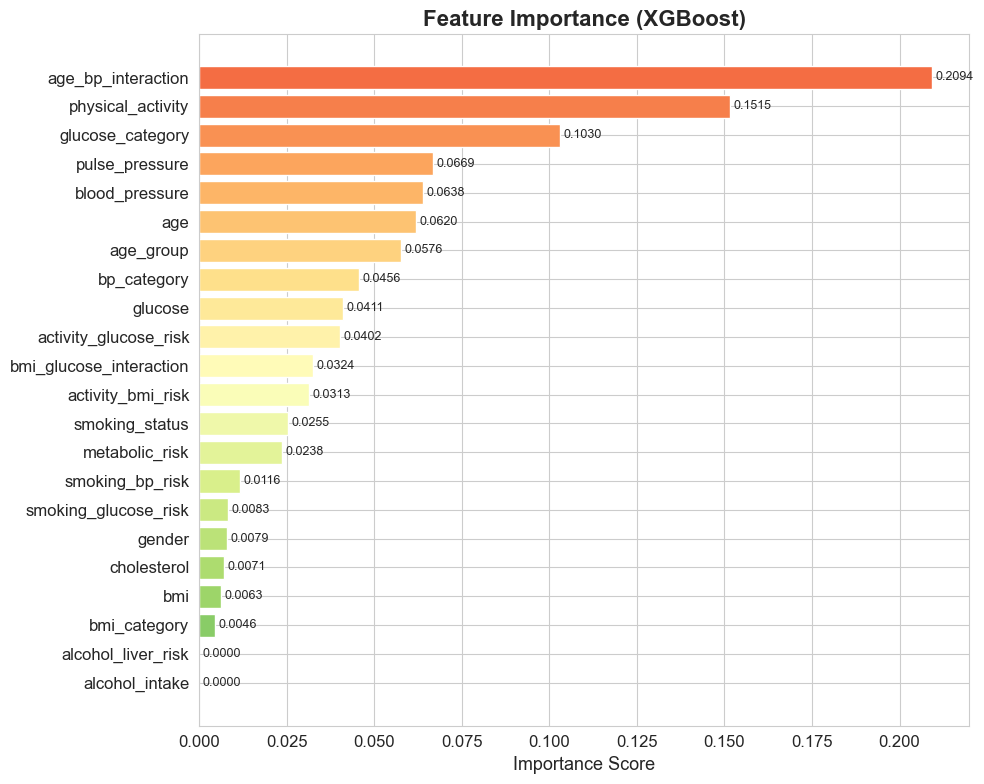

Top 10 Most Important Features:
              Feature  Importance
   age_bp_interaction    0.209403
    physical_activity    0.151530
     glucose_category    0.103041
       pulse_pressure    0.066881
       blood_pressure    0.063824
                  age    0.062039
            age_group    0.057598
          bp_category    0.045558
              glucose    0.041101
activity_glucose_risk    0.040203


In [13]:
importance = xgb.feature_importances_
feat_imp = pd.DataFrame({'Feature': FEATURE_COLS, 'Importance': importance})
feat_imp = feat_imp.sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))
colors_imp = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(feat_imp)))
bars = plt.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors_imp)
plt.xlabel('Importance Score', fontsize=13)
plt.title('Feature Importance (XGBoost)', fontsize=16, fontweight='bold')

for bar, val in zip(bars, feat_imp['Importance']):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print('Top 10 Most Important Features:')
print(feat_imp.sort_values('Importance', ascending=False).head(10).to_string(index=False))

## 13. Cross-Validation Results

Running 3-Fold Stratified Cross-Validation...



3-Fold CV Results:
  ROC-AUC:  0.9166 +/- 0.0011  (folds: [0.9154 0.918  0.9162])
  Accuracy: 0.8378 +/- 0.0015  (folds: [0.836  0.8396 0.8379])
  F1 Score: 0.8391 +/- 0.0016  (folds: [0.8372 0.8412 0.8388])


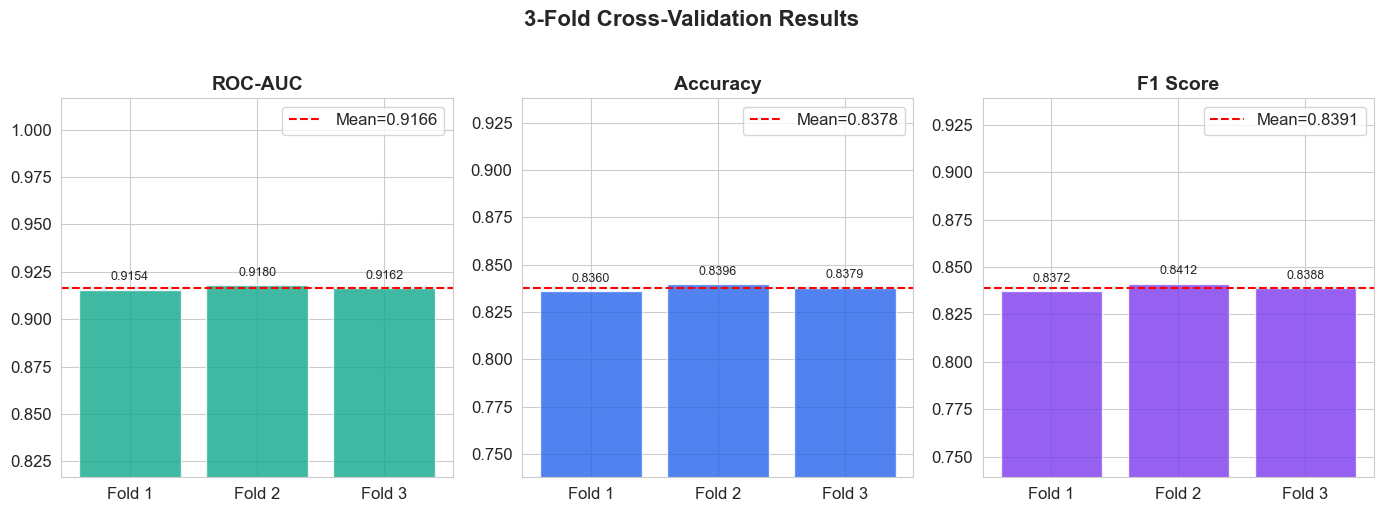

In [14]:
print('Running 3-Fold Stratified Cross-Validation...')
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cv_auc = cross_val_score(ensemble, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=1)
cv_acc = cross_val_score(ensemble, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=1)
cv_f1 = cross_val_score(ensemble, X_train, y_train, cv=cv, scoring='f1', n_jobs=1)

print(f'\n3-Fold CV Results:')
print(f'  ROC-AUC:  {cv_auc.mean():.4f} +/- {cv_auc.std():.4f}  (folds: {cv_auc.round(4)})')
print(f'  Accuracy: {cv_acc.mean():.4f} +/- {cv_acc.std():.4f}  (folds: {cv_acc.round(4)})')
print(f'  F1 Score: {cv_f1.mean():.4f} +/- {cv_f1.std():.4f}  (folds: {cv_f1.round(4)})')

# Plot CV results
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
folds = [f'Fold {i+1}' for i in range(3)]

for ax, scores, name, color in zip(axes,
    [cv_auc, cv_acc, cv_f1],
    ['ROC-AUC', 'Accuracy', 'F1 Score'],
    ['#0fa88a', '#2563eb', '#7c3aed']):
    
    ax.bar(folds, scores, color=color, alpha=0.8)
    ax.axhline(y=scores.mean(), color='red', linestyle='--', label=f'Mean={scores.mean():.4f}')
    ax.set_ylim(scores.mean() - 0.1, scores.mean() + 0.1)
    ax.set_title(name, fontsize=14, fontweight='bold')
    ax.legend()
    for i, v in enumerate(scores):
        ax.text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=9)

plt.suptitle('3-Fold Cross-Validation Results', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 14. Feature Correlation Heatmap

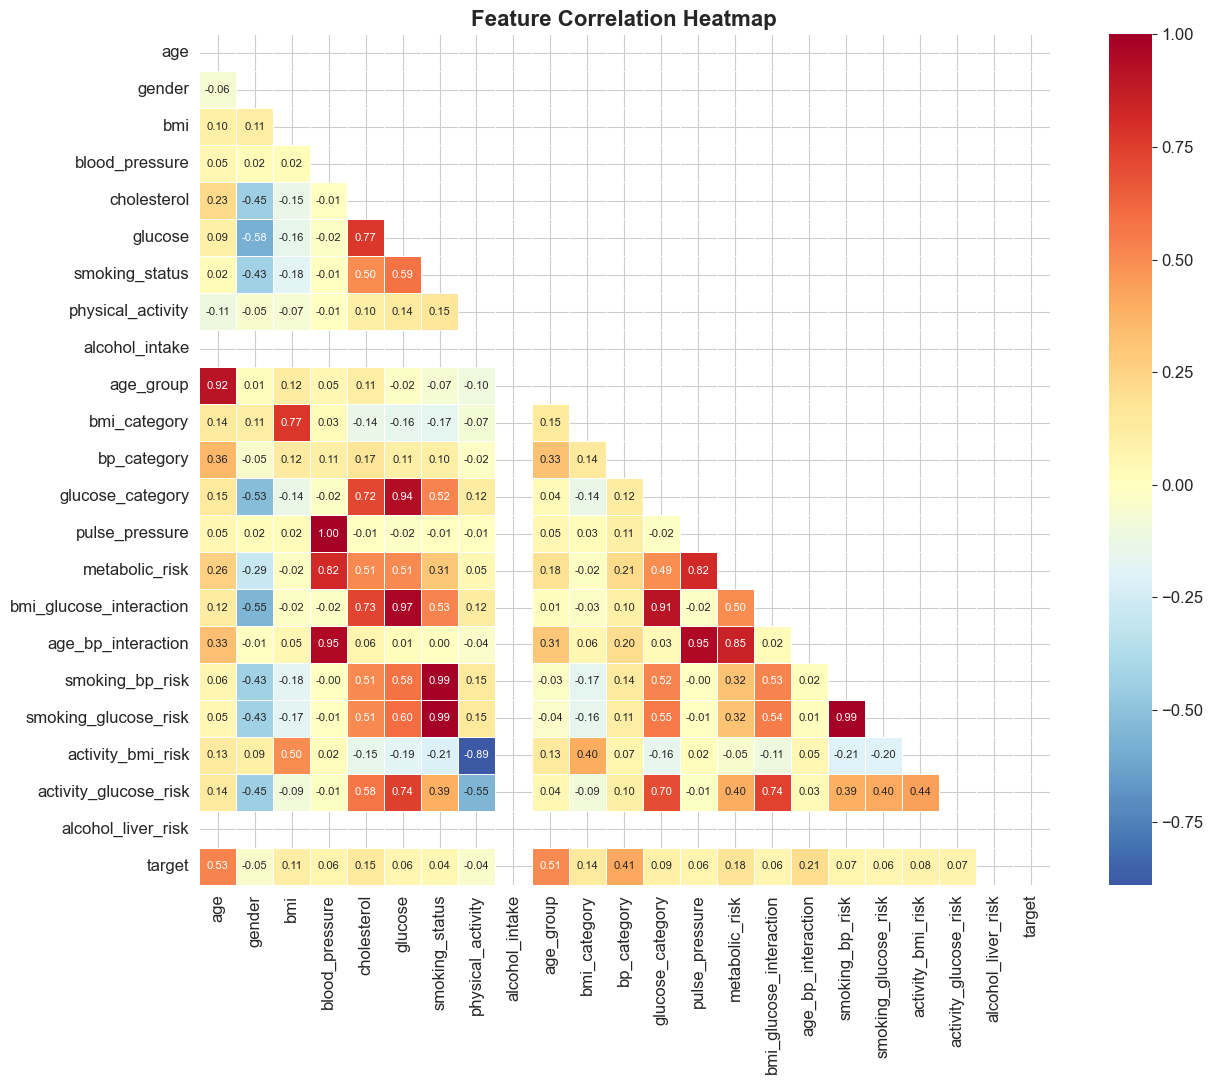

In [15]:
corr = df[FEATURE_COLS + ['target']].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 15. Target Distribution by Key Features

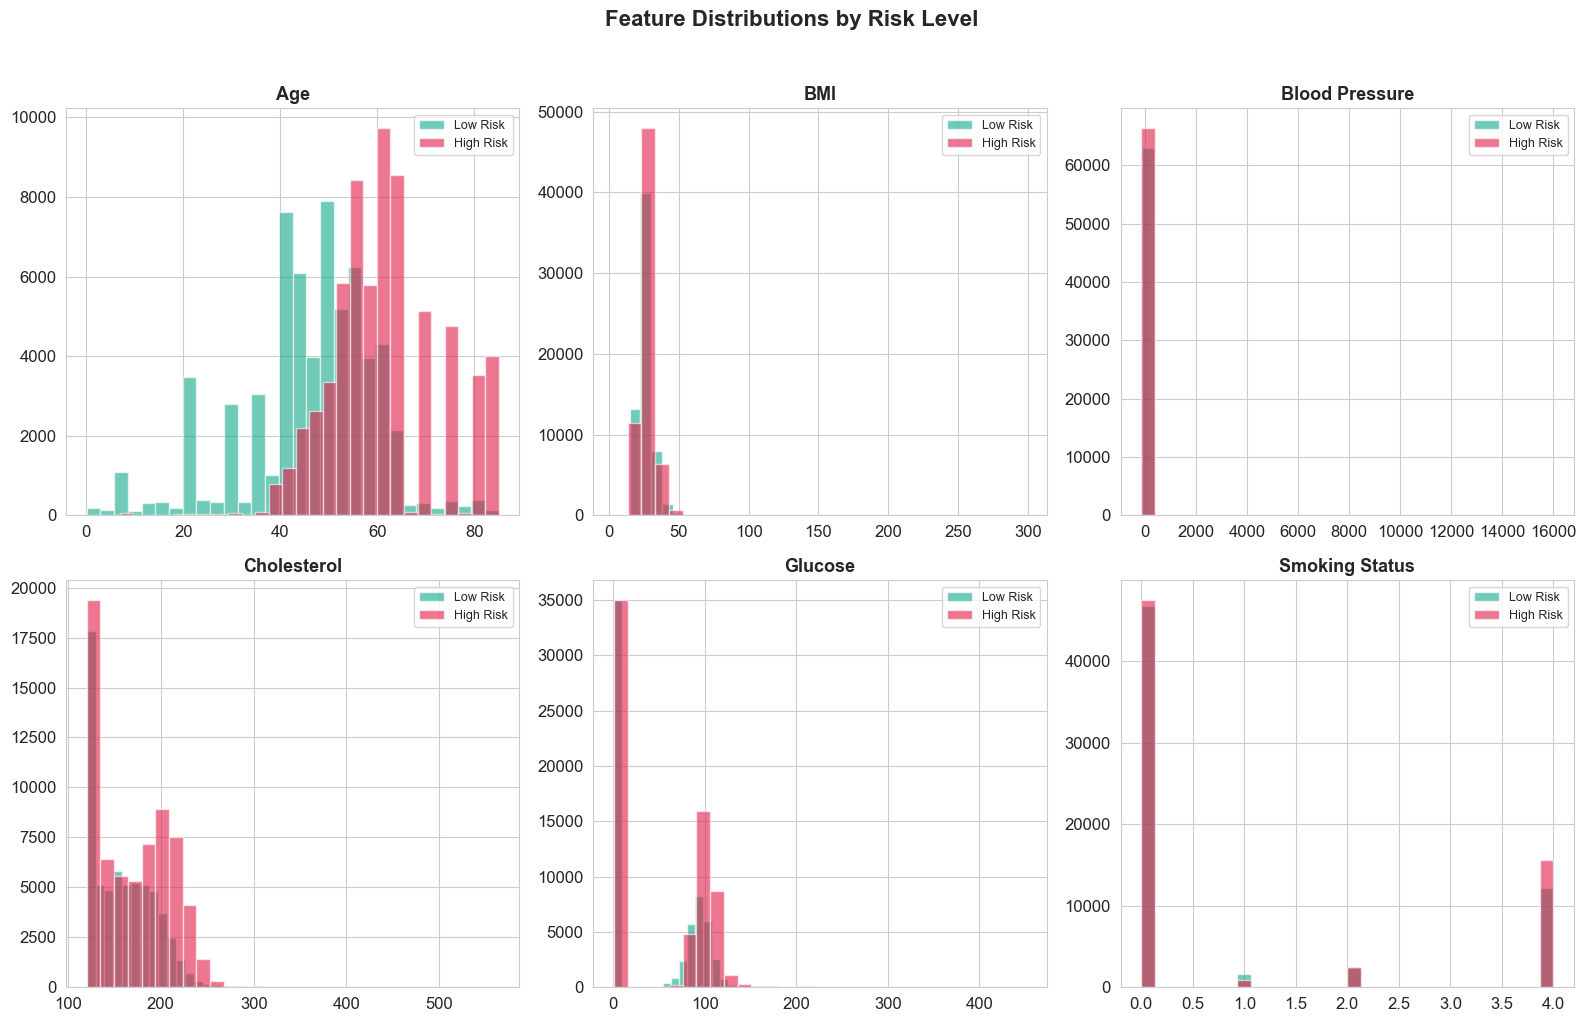

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

key_features = ['age', 'bmi', 'blood_pressure', 'cholesterol', 'glucose', 'smoking_status']
titles = ['Age', 'BMI', 'Blood Pressure', 'Cholesterol', 'Glucose', 'Smoking Status']

for ax, feat, title in zip(axes.flat, key_features, titles):
    for target_val, label, color in [(0, 'Low Risk', '#0fa88a'), (1, 'High Risk', '#e11d48')]:
        subset = df[df['target'] == target_val][feat]
        ax.hist(subset, bins=30, alpha=0.6, label=label, color=color, edgecolor='white')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Feature Distributions by Risk Level', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 16. Save Model & Metadata

In [17]:
joblib.dump(ensemble, 'model.pkl')
print('Ensemble model saved as model.pkl')

metadata = {
    'model_type': 'VotingClassifier (XGBoost + RF + GB + LR)',
    'threshold': float(best_threshold),
    'features': FEATURE_COLS,
    'accuracy': float(accuracy_score(y_test, y_pred)),
    'roc_auc': float(roc_auc_score(y_test, y_probs)),
    'f1': float(f1_score(y_test, y_pred)),
    'precision': float(precision_score(y_test, y_pred)),
    'recall': float(recall_score(y_test, y_pred)),
    'cv_roc_auc_mean': float(cv_auc.mean()),
    'cv_roc_auc_std': float(cv_auc.std()),
    'cv_accuracy_mean': float(cv_acc.mean()),
    'datasets_used': ['Heart Disease UCI', 'PIMA Diabetes', 'Stroke', 'NHANES', 'Cardiovascular', 'BRFSS 2022']
}

with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print('Metadata saved as model_metadata.json')
print(f'\nFinal Metrics:')
print(f'  Accuracy:  {metadata["accuracy"]:.4f}')
print(f'  ROC-AUC:   {metadata["roc_auc"]:.4f}')
print(f'  F1 Score:  {metadata["f1"]:.4f}')
print(f'  Precision: {metadata["precision"]:.4f}')
print(f'  Recall:    {metadata["recall"]:.4f}')

Ensemble model saved as model.pkl
Metadata saved as model_metadata.json

Final Metrics:
  Accuracy:  0.8351
  ROC-AUC:   0.9157
  F1 Score:  0.8426
  Precision: 0.8261
  Recall:    0.8598
